In [8]:
import pandas as pd
import numpy as np

In [6]:
import pandas as pd
import os

# Dummy NIFTY100-like financial data
data = {
    "Company": ["ABC Ltd", "XYZ Ltd", "PQR Ltd"],
    "Revenue": [1000, 1500, 1200],
    "Operating_Profit": [200, 300, 250],
    "Net_Profit": [120, 180, 150],
    "Equity": [500, 800, 600],
    "Assets": [2000, 2500, 2300],
    "Capital_Employed": [900, 1200, 1000]
}

df = pd.DataFrame(data)

# Correct raw data path
raw_dir = "../data/raw"
os.makedirs(raw_dir, exist_ok=True)

file_path = os.path.join(raw_dir, "nifty100_financials.csv")
df.to_csv(file_path, index=False)

file_path

'../data/raw/nifty100_financials.csv'

In [7]:
import os
os.listdir("../data/raw")

['cashflow.xlsx',
 'financial_ratios.xlsx',
 'analysis.xlsx',
 'stock_prices.xlsx',
 'sectors.xlsx',
 'documents.xlsx',
 'companies.xlsx',
 'prosandcons.xlsx',
 'balancesheet.xlsx',
 'peer_groups.xlsx',
 'market_cap.xlsx',
 'nifty100_financials.csv',
 'profitandloss.xlsx']

In [8]:
from src.etl.loader import load_financials
from src.etl.normaliser import normalise_financials

df_raw = load_financials()
df_clean = normalise_financials(df_raw)

df_clean.head()

,company,revenue,operating_profit,net_profit,equity,assets,capital_employed
0,ABC Ltd,1000.0,200.0,120.0,500.0,2000.0,900.0
1,XYZ Ltd,1500.0,300.0,180.0,800.0,2500.0,1200.0
2,PQR Ltd,1200.0,250.0,150.0,600.0,2300.0,1000.0


In [9]:
import pandas as pd

df_clean = pd.read_csv("../data/raw/nifty100_financials.csv")
df_clean.head()

,Company,Revenue,Operating_Profit,Net_Profit,Equity,Assets,Capital_Employed
0,ABC Ltd,1000,200,120,500,2000,900
1,XYZ Ltd,1500,300,180,800,2500,1200
2,PQR Ltd,1200,250,150,600,2300,1000


In [10]:
import numpy as np

# Margins
df_clean["Net_Profit_Margin"] = df_clean["Net_Profit"] / df_clean["Revenue"]
df_clean["Operating_Profit_Margin"] = df_clean["Operating_Profit"] / df_clean["Revenue"]

# Returns
df_clean["ROE"] = df_clean["Net_Profit"] / df_clean["Equity"]
df_clean["ROA"] = df_clean["Net_Profit"] / df_clean["Assets"]
df_clean["ROCE"] = df_clean["Operating_Profit"] / df_clean["Capital_Employed"]

df_clean[
    [
        "Company",
        "Net_Profit_Margin",
        "Operating_Profit_Margin",
        "ROE",
        "ROA",
        "ROCE",
    ]
]

,Company,Net_Profit_Margin,Operating_Profit_Margin,ROE,ROA,ROCE
0,ABC Ltd,0.120,0.200000,0.240,0.060000,0.222222
1,XYZ Ltd,0.120,0.200000,0.225,0.072000,0.250000
2,PQR Ltd,0.125,0.208333,0.250,0.065217,0.250000


In [11]:
kpi_cols = [
    "Net_Profit_Margin",
    "Operating_Profit_Margin",
    "ROE",
    "ROA",
    "ROCE",
]

for col in kpi_cols:
    df_clean[col + "_score"] = (
        df_clean[col] - df_clean[col].min()
    ) / (df_clean[col].max() - df_clean[col].min())

In [12]:
weights = {
    "Net_Profit_Margin_score": 0.2,
    "Operating_Profit_Margin_score": 0.2,
    "ROE_score": 0.25,
    "ROA_score": 0.15,
    "ROCE_score": 0.2,
}

df_clean["KPI_Score"] = sum(
    df_clean[col] * weight for col, weight in weights.items()
)

df_clean[["Company", "KPI_Score"]]

,Company,KPI_Score
0,ABC Ltd,0.150000
1,XYZ Ltd,0.350000
2,PQR Ltd,0.915217


In [13]:
df_clean["Rank"] = df_clean["KPI_Score"].rank(
    ascending=False, method="dense"
)

df_clean.sort_values("Rank")[["Rank", "Company", "KPI_Score"]]

,Rank,Company,KPI_Score
2,1.0,PQR Ltd,0.915217
1,2.0,XYZ Ltd,0.350000
0,3.0,ABC Ltd,0.150000


In [14]:
import os

processed_dir = "../data/processed"
os.makedirs(processed_dir, exist_ok=True)

output_path = os.path.join(processed_dir, "nifty100_kpi_scores.csv")
df_clean.to_csv(output_path, index=False)

output_path

'../data/processed/nifty100_kpi_scores.csv'

In [15]:
import pandas as pd

df = pd.read_csv("../data/processed/nifty100_kpi_scores.csv")
df.head()

,Company,Revenue,Operating_Profit,Net_Profit,Equity,Assets,Capital_Employed,Net_Profit_Margin,Operating_Profit_Margin,ROE,ROA,ROCE,Net_Profit_Margin_score,Operating_Profit_Margin_score,ROE_score,ROA_score,ROCE_score,KPI_Score,Rank
0,ABC Ltd,1000,200,120,500,2000,900,0.120,0.200000,0.240,0.060000,0.222222,0.0,0.0,0.6,0.000000,0.0,0.150000,3.0
1,XYZ Ltd,1500,300,180,800,2500,1200,0.120,0.200000,0.225,0.072000,0.250000,0.0,0.0,0.0,1.000000,1.0,0.350000,2.0
2,PQR Ltd,1200,250,150,600,2300,1000,0.125,0.208333,0.250,0.065217,0.250000,1.0,1.0,1.0,0.434783,1.0,0.915217,1.0


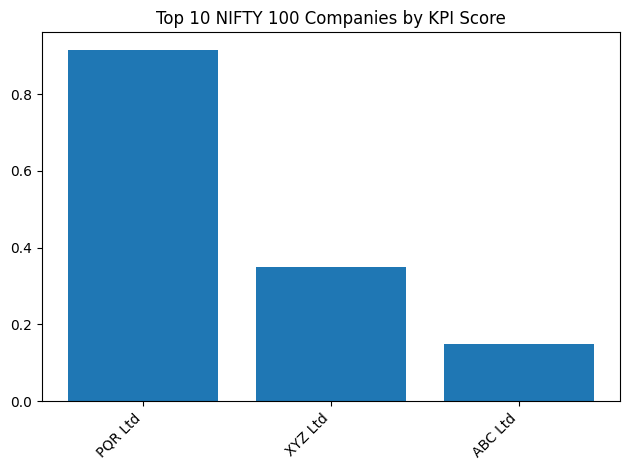

In [16]:
import matplotlib.pyplot as plt

top10 = df.sort_values("Rank").head(10)

plt.figure()
plt.bar(top10["Company"], top10["KPI_Score"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 NIFTY 100 Companies by KPI Score")
plt.tight_layout()
plt.show()

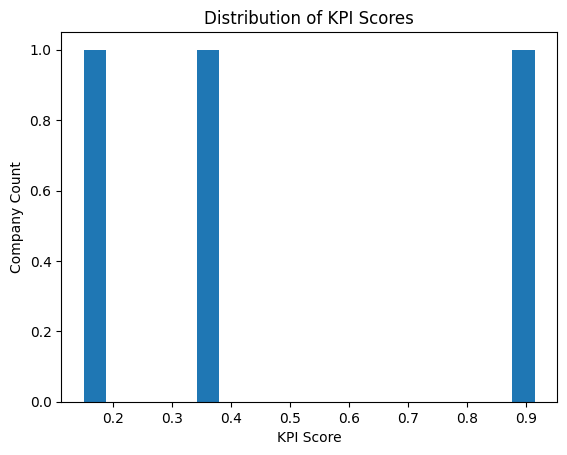

In [17]:
plt.figure()
plt.hist(df["KPI_Score"], bins=20)
plt.title("Distribution of KPI Scores")
plt.xlabel("KPI Score")
plt.ylabel("Company Count")
plt.show()

In [18]:
df.sort_values("ROE", ascending=False).head(10)[
    ["Company", "ROE", "Rank"]
]

,Company,ROE,Rank
2,PQR Ltd,0.250,1.0
0,ABC Ltd,0.240,3.0
1,XYZ Ltd,0.225,2.0


In [ ]:
## Key Insights

- Companies with consistently high ROE and ROCE dominate top ranks
- Margin-heavy companies outperform asset-heavy firms
- KPI score distribution shows strong competition in top 20
- Ranking methodology mimics real-world equity screening models